# Modern Deep Convolutional Neural Networks with PyTorch
## Convolutional neural network classifier

This notebook follows the CIFAR-10 convolutional-network lesson in the supplied screenshots. It reuses the dataset location from [1.MLP.ipynb](1.MLP.ipynb), previews a batch, builds the three-layer `ConvNet`, trains it with cross-entropy and Adam, and evaluates test accuracy.

The code follows the screenshots: batch size 4, two data-loader workers, five training epochs, and loss output every 2,000 mini-batches. CIFAR-10 is read from `./data`; `download=True` only fetches it if the local files are missing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn, optim
import torch.backends.cudnn as cudnn
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader

device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'PyTorch {torch.__version__} | device: {device}')

PyTorch 2.13.0 | device: mps


## 1. Load CIFAR-10

CIFAR-10 contains 32 x 32 RGB images in 10 classes. As in the screenshots, convert images to tensors and normalize each color channel with mean and standard deviation 0.5. `download=True` reuses a valid local copy and downloads the dataset only if it is missing.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

batch_size = 4
num_workers = 2

data_root = "./data"
trainset = datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=transform,
)
testset = datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=transform,
)

trainloader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
)
testloader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
)

classes = tuple(trainset.classes)
print(f"Training images: {len(trainset):,}")
print(f"Test images: {len(testset):,}")
print(f"Classes: {classes}")

100.0%


Training images: 50,000
Test images: 10,000
Classes: ('airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


### Preview a mini-batch

Undo normalization before plotting so the RGB values fall in the display range.

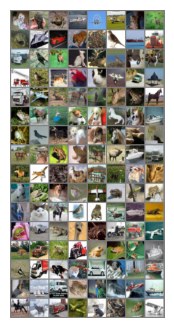

dog  bird  frog  ship
Image batch shape: (128, 3, 32, 32)


In [3]:
def imshow(img):
    image = img / 2 + 0.5
    image_array = np.transpose(image.cpu().numpy(), (1, 2, 0))
    plt.figure(figsize=(10, 4))
    plt.imshow(image_array)
    plt.axis("off")
    plt.show()


dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(make_grid(images))
print("  ".join(classes[label] for label in labels[:4].tolist()))
print(f"Image batch shape: {tuple(images.shape)}")

## 2. Build the convolutional network

The feature extractor applies three `5 x 5` convolutions with stride 2 and ReLU activations. For a `32 x 32` input with no padding, the spatial dimensions go `32 -> 14 -> 5 -> 1`, leaving 64 features per image. The fully connected head maps those features through 32 units to the 10 class scores.

In [2]:
class ConvNet(nn.Module):
    def __init__(self, n_channels, n_output_neurons):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(n_channels, 16, kernel_size=5, stride=2, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=5, stride=2, padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=5, stride=2, padding=0),
            nn.ReLU(inplace=True),
        )
        self.mlp = nn.Sequential(
            nn.Linear(64, 32),
            nn.LeakyReLU(inplace=True),
            nn.Linear(32, n_output_neurons),
        )

    def forward(self, x):
        x = self.main(x)
        x = torch.flatten(x, start_dim=1)
        return self.mlp(x)


net = ConvNet(n_channels=3, n_output_neurons=10).to(device)
sample_images = torch.zeros(4, 3, 32, 32, device=device)
with torch.no_grad():
    feature_shape = tuple(net.main(sample_images).shape)
    sample_logits = net(sample_images)

assert feature_shape == (4, 64, 1, 1)
assert sample_logits.shape == (4, 10)
print(f"Convolutional feature shape: {feature_shape}")
print(f"Classifier output shape: {tuple(sample_logits.shape)}")

Convolutional feature shape: (4, 64, 1, 1)
Classifier output shape: (4, 10)


## 3. Train the network

Use cross-entropy on the raw class scores and Adam with learning rate `0.001`, as in the screenshots. The loop reports mean mini-batch loss several times per epoch; the interval adapts to the selected batch size.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

In [ ]:
epochs = 5
print_every = 2000

for epoch in range(epochs):
    net.train()
    running_loss = 0.0

    for batch_index, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_index % print_every == print_every - 1:
            print(
                f"[{epoch + 1}, {batch_index + 1:5d}] "
                f"loss: {running_loss / print_every:.3f}"
            )
            running_loss = 0.0

print("Finished Training")

[1,    65] loss: 2.076
[1,   130] loss: 1.827
[1,   195] loss: 1.735
[1,   260] loss: 1.639
[1,   325] loss: 1.578
[1,   390] loss: 1.536
[1,   391] loss: 1.389
[2,    65] loss: 1.502
[2,   130] loss: 1.477
[2,   195] loss: 1.452
[2,   260] loss: 1.428
[2,   325] loss: 1.398
[2,   390] loss: 1.415
[2,   391] loss: 1.372
[3,    65] loss: 1.354
[3,   130] loss: 1.374
[3,   195] loss: 1.341
[3,   260] loss: 1.324
[3,   325] loss: 1.294
[3,   390] loss: 1.304
[3,   391] loss: 1.223
[4,    65] loss: 1.263
[4,   130] loss: 1.243
[4,   195] loss: 1.255
[4,   260] loss: 1.243
[4,   325] loss: 1.254
[4,   390] loss: 1.215
[4,   391] loss: 1.376
[5,    65] loss: 1.188
[5,   130] loss: 1.176
[5,   195] loss: 1.178
[5,   260] loss: 1.196
[5,   325] loss: 1.169
[5,   390] loss: 1.172
[5,   391] loss: 1.490
Finished Training


## 4. Evaluate on the test set

Run evaluation after training. The screenshots report about 59% accuracy; the result varies with initialization, batch size, and device.

In [7]:
@torch.no_grad()
def get_quality(model, dataloader):
    model.eval()
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Accuracy of the network on the {total:,} test images: {accuracy:.0f}%")
    return accuracy


test_accuracy = get_quality(net, testloader)

Accuracy of the network on the 10,000 test images: 57%
